In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Nama file yang sudah di-upload
nama_file = 'winequality-red.csv'

# Dataset ini menggunakan titik koma (;) sebagai pemisah, bukan koma
# Jadi kita perlu tambahkan parameter sep=';'
df = pd.read_csv(nama_file, sep=';')

# Tampilkan 5 baris pertama
print("Data Awal:")
print(df.head())

# Dapatkan ringkasan statistik dari semua kolom
print("\nRingkasan Statistik:")
print(df.describe())

Data Awal:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.

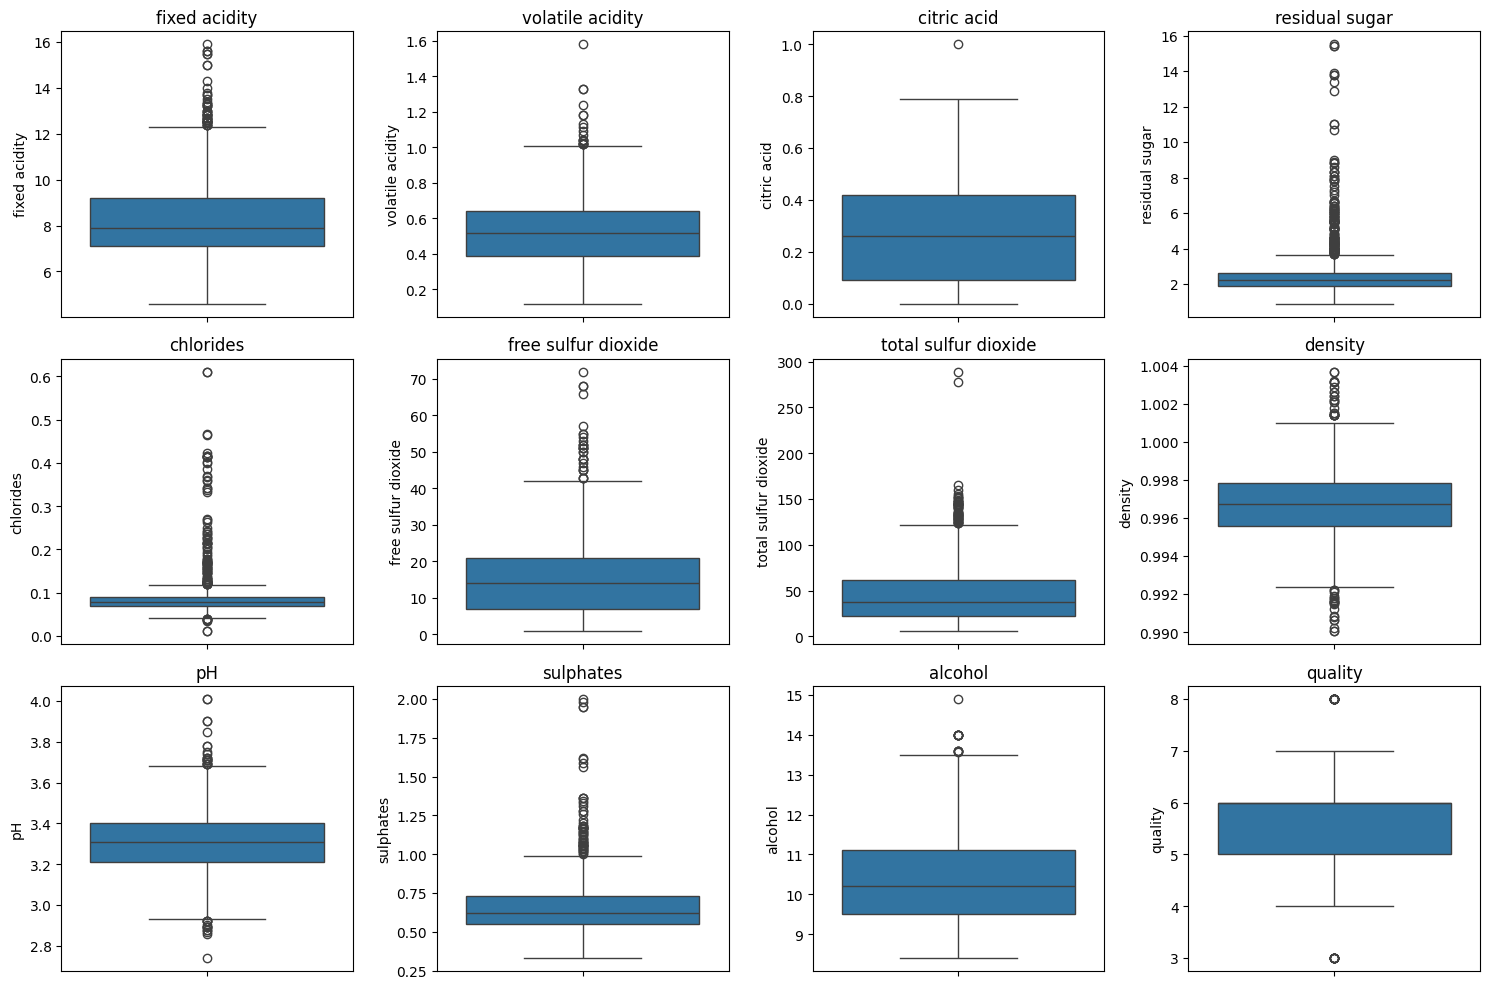

In [ ]:
# Membuat box plot untuk setiap kolom fitur untuk melihat outlier
plt.figure(figsize=(15, 10)) # Mengatur ukuran gambar agar lebih besar dan jelas

# Loop melalui setiap nama kolom di dataframe
for i, column in enumerate(df.columns):
    plt.subplot(3, 4, i + 1) # Membuat grid 3x4 untuk plot
    sns.boxplot(y=df[column]) # Membuat boxplot untuk kolom saat ini
    plt.title(column) # Memberi judul pada plot

plt.tight_layout() # Merapikan layout agar tidak tumpang tindih
plt.show()

In [ ]:
# 1. Hitung IQR untuk kolom 'total sulfur dioxide'
Q1 = df['total sulfur dioxide'].quantile(0.25)
Q3 = df['total sulfur dioxide'].quantile(0.75)
IQR = Q3 - Q1

# 2. Tentukan batas atas dan batas bawah
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

print(f"Kolom 'total sulfur dioxide'")
print(f"Batas Bawah: {batas_bawah}")
print(f"Batas Atas: {batas_atas}")

# 3. Buat dataframe baru untuk menampung data yang sudah bersih
df_cleaned = df.copy()

# 4. Lakukan Capping: Ganti nilai outlier
# Jika nilai > batas_atas, ganti dengan batas_atas
# Jika nilai < batas_bawah, ganti dengan batas_bawah
df_cleaned['total sulfur dioxide'] = np.where(
    df_cleaned['total sulfur dioxide'] > batas_atas,  # Kondisi
    batas_atas,  # Nilai jika True
    df_cleaned['total sulfur dioxide']  # Nilai jika False
)
df_cleaned['total sulfur dioxide'] = np.where(
    df_cleaned['total sulfur dioxide'] < batas_bawah, # Kondisi
    batas_bawah, # Nilai jika True
    df_cleaned['total sulfur dioxide'] # Nilai jika False
)

Kolom 'total sulfur dioxide'
Batas Bawah: -38.0
Batas Atas: 122.0


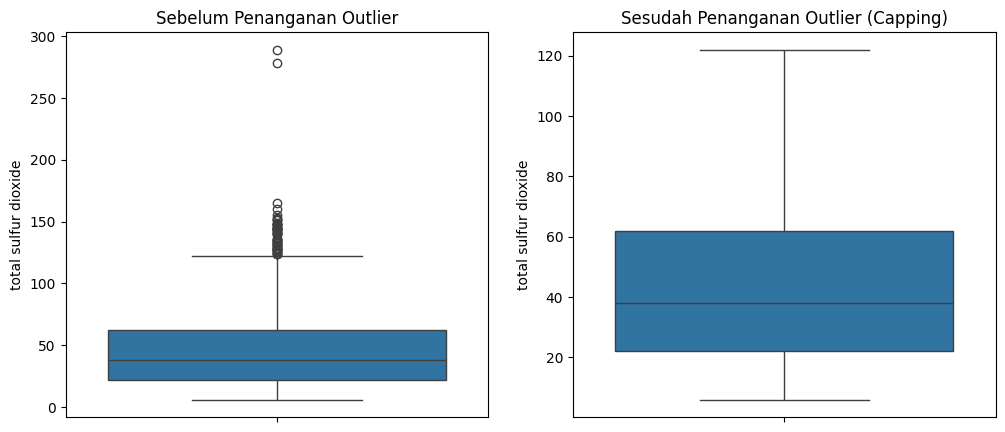

In [ ]:
# Membuat perbandingan visual
plt.figure(figsize=(12, 5))

# Plot sebelum dibersihkan
plt.subplot(1, 2, 1)
sns.boxplot(y=df['total sulfur dioxide'])
plt.title("Sebelum Penanganan Outlier")

# Plot sesudah dibersihkan
plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned['total sulfur dioxide'])
plt.title("Sesudah Penanganan Outlier (Capping)")

plt.show()